# 02 — Macro and geospatial context

This notebook places each Ames sale in time and space. The pre-split CSVs have no price index
and no coordinates, so it adds CPI, the FHFA and Case-Shiller house price indices, mortgage
rates, Zillow's ZHVI and property coordinates. The central fact, in §1, is that Ames fell 4.3%
peak-to-trough while the country fell 27.4%; that caveat attaches to every result in the
project. The notebook also finds that the apparent price premium for living near campus
disappears once house age is controlled for, and cross-checks the 2026 values used for
investment analysis against an independent source.

Terms are defined in [the glossary](../docs/GLOSSARY.md).

Three questions:

1. **What happened to Ames prices 2006–2010?** Nominal medians say "roughly
   flat". Deflating by CPI (converting to *real*, inflation-adjusted, terms) and benchmarking
   against Case-Shiller gives a more informative picture, and explains why the temporal split
   in notebook 03 is a fair test rather than a rigged one.
2. **Could anyone afford them?** Price is half the story; the monthly payment at the
   prevailing mortgage rate is the half that binds. Payment-to-income is tracked through
   the cycle, along with the price sensitivity to a ±200 bp rate move (one basis point is
   one hundredth of a percent).
3. **Where is the value?** Ames is a college town, so the price gradient from
   Iowa State's campus is measured directly.

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.spatial import ConvexHull

from ames.compat import silence_spurious_matmul_warnings, worker_warning_filter
from ames.config import (ARMS_LENGTH_CONDITION, CCAR_SEVERELY_ADVERSE_HPI_SHOCK,
                         DOWNTOWN_AMES, ISU_CAMPUS, PROCESSED, REPORTS)
from ames.data import AMES_CBSA, load_macro, load_metro_hpi, load_properties
from ames.metro import (CRISIS_END, CRISIS_START, drawdowns, percentile_of,
                        severity_of, shock_at_quantile)
from ames.features import haversine_miles, prepare
from ames.finance import monthly_payment
from ames.viz import (AQUA, BLUE, CATEGORICAL_3, CONTEXT, CONTEXT_DARK, CONTRAST,
                      CONTRAST_FILL, DIVERGING, GRID, INK_MUTED, INK_SECONDARY,
                      ORANGE, PANEL, SEQUENTIAL, STATUS, SUBJECT, SUBJECT_FILL,
                      SURFACE, VIOLET, annotate, axis_note, band, bar_labels,
                      callout, dumbbell, emphasise, era, fig_titled, hero,
                      label_end, legend_above, money, pct, pct1, reference_line,
                      save, titled, use_style)

use_style()

# The figure furniture every chart in this notebook shares: which notebook you are in,
# and where the numbers came from.  Defined once so the nine notebooks read as one report.
KICKER = "02 · Macro & geography"
SOURCE = "Sources: FHFA, S&P Case-Shiller, Freddie Mac PMMS, BLS CPI, Zillow Research (via FRED)."

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

silence_spurious_matmul_warnings()

props = prepare(load_properties())
macro = load_macro()
normal = props[props["Sale Condition"] == ARMS_LENGTH_CONDITION]
print(f"{len(props):,} sales, {len(normal):,} arm's-length")
print(f"macro panel: {macro.index.min():%Y-%m} to {macro.index.max():%Y-%m}")

2,930 sales, 2,413 arm's-length
macro panel: 1947-01 to 2026-09


## 1. Ames versus the crash

Both series are indexed to 100 at 2006-Q1, which is how two indices with different bases can
share one axis.

In [2]:
window = macro.loc["2000-01-01":"2016-12-31", ["hpi_ames_msa", "hpi_case_shiller_us"]]
base = window.loc["2006-01-01"]
indexed = window / base * 100

trough = indexed.loc["2006-01-01":"2012-12-31"].min()
peak = indexed.loc["2000-01-01":"2008-12-31"].max()
drawdown = (trough / peak - 1).rename("peak-to-trough, 2006–2012")
drawdown.to_frame().round(3)

,"peak-to-trough, 2006–2012"
hpi_ames_msa,-0.043
hpi_case_shiller_us,-0.274


  saved reports/figures/02_ames_vs_national.png


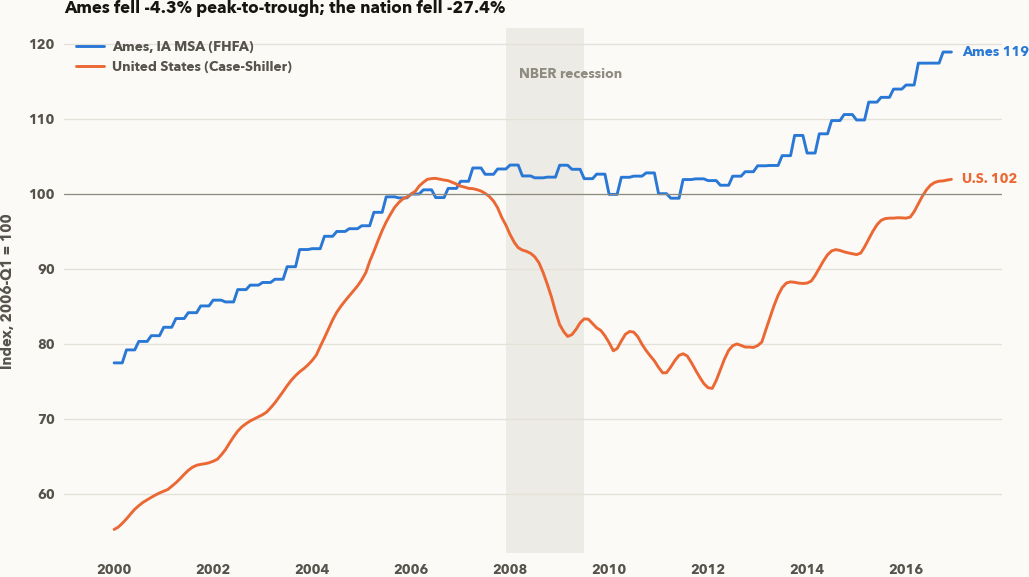

In [3]:
fig, ax = plt.subplots(figsize=(11.0, 6.2))
ax.plot(indexed.index, indexed["hpi_ames_msa"], color=BLUE, label="Ames, IA MSA (FHFA)")
ax.plot(indexed.index, indexed["hpi_case_shiller_us"], color=ORANGE,
        label="United States (Case-Shiller)")
ax.axhline(100, color=INK_MUTED, lw=0.8)
ax.axvspan(pd.Timestamp("2007-12-01"), pd.Timestamp("2009-06-30"),
           color=GRID, alpha=0.6, lw=0)
annotate(ax, pd.Timestamp("2008-01-01"), ax.get_ylim()[1] * 0.97, "NBER recession",
         offset=(6, -12), color=INK_MUTED)
for name, color, label in [("hpi_ames_msa", BLUE, "Ames"),
                           ("hpi_case_shiller_us", ORANGE, "U.S.")]:
    last = indexed[name].dropna()
    annotate(ax, last.index[-1], last.iloc[-1], f"{label} {last.iloc[-1]:.0f}", color=color)
ax.set_ylabel("Index, 2006-Q1 = 100")
ax.legend(loc="upper left")
ax.margins(x=0.06)
ax.set_title(f"Ames fell {drawdown['hpi_ames_msa']:.1%} peak-to-trough; "
             f"the nation fell {drawdown['hpi_case_shiller_us']:.1%}")
save(fig, "02_ames_vs_national")
plt.show()

Ames barely participated in either the bubble or the bust, and this is the most important
piece of context in the project. Iowa State University employs a large,
stable share of the local workforce and generates non-cyclical housing demand, so the
2006–2010 window in this dataset is not a crash sample in the way a Phoenix or Las
Vegas sample would be.

Two consequences follow:

- The temporal split in notebook 03 is a mild regime shift rather than a stress test. Any
  degradation measured there is a lower bound on what a more cyclical market would show.
- The credit stress in notebook 08 cannot rely on the historical path. It
  applies the supervisory −30% shock explicitly, because Ames's own history does not
  contain one.

  saved reports/figures/02_real_price_path.png


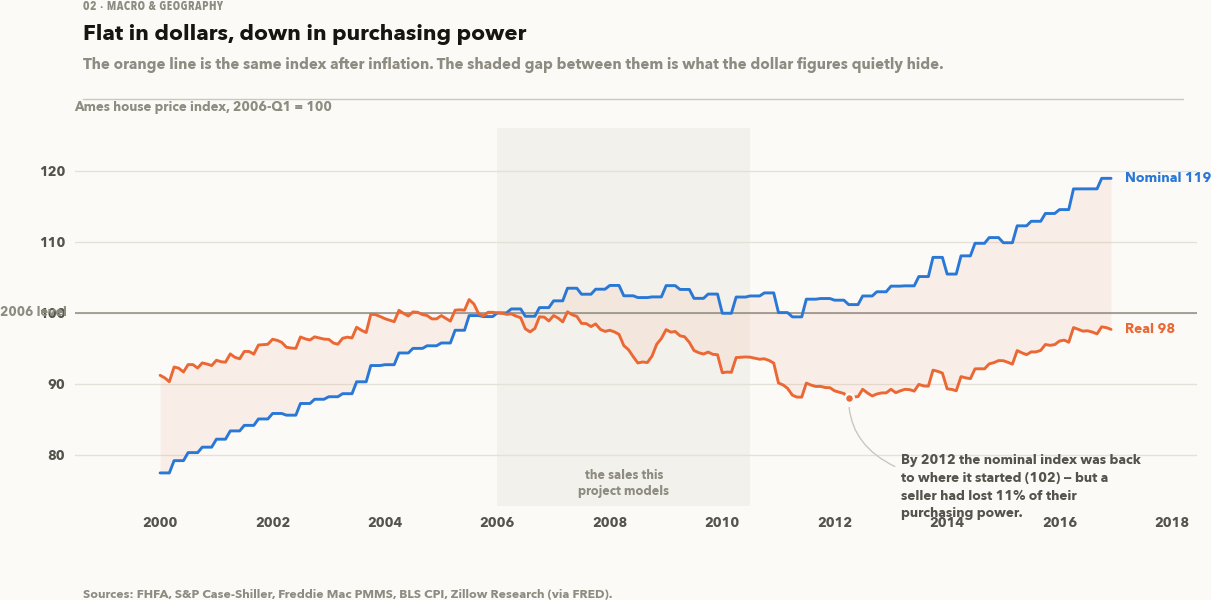

In [4]:
real = macro.loc["2000-01-01":"2016-12-31"].copy()
real["ames_real"] = real["hpi_ames_msa"] * real["cpi_deflator_2026"]
real_indexed = real[["hpi_ames_msa", "ames_real"]] / real[["hpi_ames_msa", "ames_real"]].loc["2006-01-01"] * 100

fig, ax = plt.subplots(figsize=(11.4, 6.0))

nominal = real_indexed["hpi_ames_msa"].dropna()
real = real_indexed["ames_real"].dropna()
real_2012 = real_indexed.loc["2012-01-01", "ames_real"]
nom_2012 = real_indexed.loc["2012-01-01", "hpi_ames_msa"]
trough_i = real.loc["2006":"2014"].idxmin()

era(ax, pd.Timestamp("2006-01-01"), pd.Timestamp("2010-07-01"),
    "the sales this\nproject models")
ax.plot(nominal.index, nominal, color=SUBJECT, lw=1.9)
ax.plot(real.index, real, color=CONTRAST, lw=1.9)
# The gap between the two lines *is* the inflation, so shade it.
ax.fill_between(real_indexed.index, real_indexed["ames_real"],
                real_indexed["hpi_ames_msa"], color=CONTRAST, alpha=0.08, lw=0)
reference_line(ax, 100, "2006 level", side="left")

label_end(ax, nominal.index[-1], nominal.iloc[-1], f"Nominal {nominal.iloc[-1]:.0f}",
          color=SUBJECT)
label_end(ax, real.index[-1], real.iloc[-1], f"Real {real.iloc[-1]:.0f}", color=CONTRAST)
callout(ax, trough_i, real.loc[trough_i],
        f"By {trough_i:%Y} the nominal index was back to where it started "
        f"({nom_2012:.0f}) — but a seller had lost {100 - real_2012:.0f}% of their "
        f"purchasing power.",
        dx=34, dy=-58, dot_color=CONTRAST, width=34)

ax.set_ylim(real_indexed.min().min() * 0.94, real_indexed.max().max() * 1.06)
ax.margins(x=0.09)
axis_note(ax, "Ames house price index, 2006-Q1 = 100")
finish(fig, "Flat in dollars, down in purchasing power",
       "The orange line is the same index after inflation. The shaded gap between them "
       "is what the dollar figures quietly hide.")
save(fig, "02_real_price_path")
plt.show()

Nominally flat is really a slow decline. By 2012 the nominal index had recovered to
101.8 (a homeowner who bought in 2006 could sell for slightly more than they paid)
while the real index sat at 89.0. In purchasing power that is an **11% loss** over
six years, with the real trough in April 2012.

Every dollar figure in notebooks 07 and 06 is nominal, as underwriting always is. This
chart is why a 3% nominal appreciation assumption is not a 3% real return, and
why `docs/ASSUMPTIONS.md` records it as roughly inflation-matching rather than as growth.

## 2. Affordability through the cycle

House prices and mortgage rates are two halves of the same constraint. What a buyer
faces is the payment.

### Ames against 410 metros, not against one national average

"Ames fell 4.3% while the nation fell 27.4%" compares Ames with an average, and the average
hides a wide spread: the national index is a blend of Merced falling
65% and Ithaca falling 4%. FHFA publishes the index for every US metropolitan area,
quarterly back to 1975, in one 4 MB file with no key, which turns the comparison into a
position in a distribution.

Each metro's peak-to-trough fall is measured from its own peak, using a running maximum inside
2005–2013. Markets did not peak on the same date, and pinning a common peak would score
late-peaking metros as milder than they were.

In [5]:
metro = load_metro_hpi()
dd = drawdowns(metro)
ames_dd = float(dd.loc[dd["cbsa"] == AMES_CBSA, "drawdown"].iloc[0])
worse_share = percentile_of(dd, AMES_CBSA)

print(f"{len(dd)} metros measured over {CRISIS_START:.0f}-{CRISIS_END:.0f}")
print(f"Ames peak-to-trough: {ames_dd:.2%}")
print(f"{worse_share:.1%} of metros fell further than Ames")
print(f"median metro: {dd['drawdown'].median():.1%}    worst: {dd['drawdown'].min():.1%}"
      f" ({dd.iloc[0]['metro']})")

severity = severity_of(dd, CCAR_SEVERELY_ADVERSE_HPI_SHOCK)
empirical_p10 = shock_at_quantile(dd, 0.10)
print(f"\nthe stress notebook 08 imposes is {CCAR_SEVERELY_ADVERSE_HPI_SHOCK:.0%}; "
      f"{severity:.1%} of metros exceeded it")
print(f"a 10th-percentile metro fell {empirical_p10:.1%}")

dd.to_parquet(PROCESSED / "metro_drawdowns.parquet", index=False)
(PROCESSED / "metro_summary.json").write_text(json.dumps({
    "n_metros": int(len(dd)),
    "ames_drawdown": ames_dd,
    "share_of_metros_worse_than_ames": worse_share,
    "median_drawdown": float(dd["drawdown"].median()),
    "worst_metro": dd.iloc[0]["metro"],
    "worst_drawdown": float(dd["drawdown"].min()),
    "imposed_shock": CCAR_SEVERELY_ADVERSE_HPI_SHOCK,
    "share_exceeding_imposed_shock": severity,
    "empirical_p10_shock": empirical_p10,
    "empirical_p05_shock": shock_at_quantile(dd, 0.05),
}, indent=2) + "\n")

dd.head(6).round(3)

410 metros measured over 2005-2013
Ames peak-to-trough: -4.26%
82.4% of metros fell further than Ames
median metro: -13.6%    worst: -65.0% (Merced, CA)

the stress notebook 08 imposes is -30%; 18.8% of metros exceeded it
a 10th-percentile metro fell -41.4%


,cbsa,metro,drawdown,peak_t,trough_t
0,32900,"Merced, CA",-0.650,2006.25,2011.25
1,29820,"Las Vegas-Henderson-North Las Vegas, NV",-0.611,2006.75,2012.00
2,33700,"Modesto, CA",-0.609,2006.00,2012.00
3,44700,"Stockton-Lodi, CA",-0.601,2006.00,2012.00
4,46700,"Vallejo, CA",-0.565,2006.25,2012.00
5,15980,"Cape Coral-Fort Myers, FL",-0.565,2006.25,2011.00


  saved reports/figures/02_metro_drawdown_distribution.png


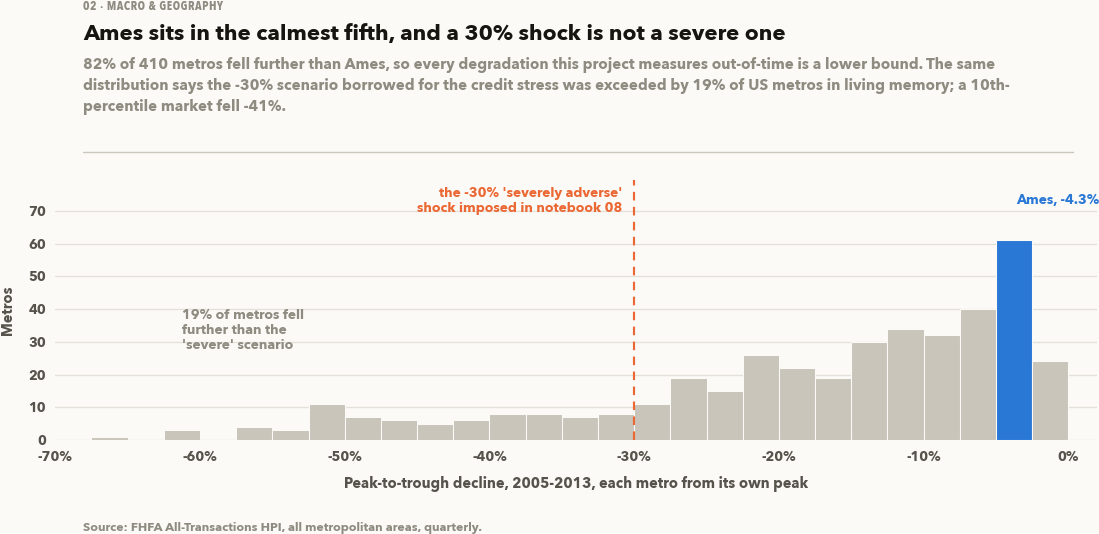

In [6]:
fig, ax = plt.subplots(figsize=(10.4, 5.4))
counts, edges, patches = ax.hist(dd["drawdown"], bins=np.arange(-0.70, 0.025, 0.025),
                                 color=CONTEXT, edgecolor=SURFACE, linewidth=0.7)
for edge, patch in zip(edges[:-1], patches):
    if edge <= ames_dd < edge + 0.025:
        patch.set_facecolor(SUBJECT)

ax.set_xlim(-0.70, 0.02)
ax.set_ylim(0, counts.max() * 1.30)
ax.xaxis.set_major_formatter(pct)
ax.set_xlabel("Peak-to-trough decline, 2005-2013, each metro from its own peak")
ax.set_ylabel("Metros")

ax.axvline(CCAR_SEVERELY_ADVERSE_HPI_SHOCK, color=CONTRAST, lw=1.4, zorder=4,
           linestyle=(0, (4, 3)))
annotate(ax, CCAR_SEVERELY_ADVERSE_HPI_SHOCK, counts.max() * 1.20,
         f"the {CCAR_SEVERELY_ADVERSE_HPI_SHOCK:.0%} 'severely adverse'\n"
         f"shock imposed in notebook 08", color=CONTRAST, ha="right", offset=(-8, 0))
annotate(ax, ames_dd, counts.max() * 1.20,
         f"Ames, {ames_dd:.1%}", color=SUBJECT, ha="left", offset=(6, 0))
annotate(ax, -0.62, counts.max() * 0.55,
         f"{severity:.0%} of metros fell\nfurther than the\n'severe' scenario",
         color=INK_MUTED, ha="left")

finish(fig, "Ames sits in the calmest fifth, and a 30% shock is not a severe one",
       f"{worse_share:.0%} of {len(dd)} metros fell further than Ames, so every "
       "degradation this project measures out-of-time is a lower bound. The same "
       f"distribution says the {CCAR_SEVERELY_ADVERSE_HPI_SHOCK:.0%} scenario borrowed "
       f"for the credit stress was exceeded by {severity:.0%} of US metros in living "
       "memory; a 10th-percentile market fell "
       f"{empirical_p10:.0%}.",
       source="Source: FHFA All-Transactions HPI, all metropolitan areas, quarterly.")
save(fig, "02_metro_drawdown_distribution")
plt.show()

The two results point in opposite directions.

Ames is calm: **82% of 410 metros fell further.** That is the basis for every
"lower bound" in this project. The temporal split barely straddles a regime change
because Ames barely had one, so the 4–7% degradation notebook 03 measures is the
mildest reading of a question that would be far harsher in Merced, Las Vegas or
Stockton, each of which lost more than 60%.

The scenario, meanwhile, is not severe: **19% of metros exceeded the 30% decline** that notebook
08 imposes as "severely adverse". That figure comes from a supervisory scenario designed for a
national portfolio. Applied to a single market it is a reasonable convention, but it is not
calibrated to how individual metros behaved. A 10th-percentile metro fell 41%.

Notebook 08 therefore runs both: the conventional shock, and one calibrated to what metros
did. Reporting the two side by side shows how much the convention understates a
plausible single-market decline.

In [7]:
# Anchor the FHFA index to observed Ames sale prices so the index becomes a dollar level.
anchor_window = slice("2006-01-01", "2010-07-01")
observed_median = normal.set_index("sale_date")["SalePrice"].sort_index().loc[anchor_window].median()
index_mean = macro.loc[anchor_window, "hpi_ames_msa"].mean()
price_level = (macro["hpi_ames_msa"] / index_mean * observed_median).rename("ames_price")

print(f"observed median arm's-length price 2006–2010: {money(observed_median)}")
print(f"anchored index -> implied 2026 Ames price:     {money(price_level.iloc[-1])}")
print(f"Zillow ZHVI, Ames MSA, latest:                 {money(macro['zhvi'].dropna().iloc[-1])}")
gap = price_level.iloc[-1] / macro["zhvi"].dropna().iloc[-1] - 1
print(f"cross-check gap:                               {gap:+.1%}")

observed median arm's-length price 2006–2010: $159k
anchored index -> implied 2026 Ames price:     $310k
Zillow ZHVI, Ames MSA, latest:                 $280k
cross-check gap:                               +10.9%


The two independent measures land about **11% apart**: the FHFA repeat-sales index
anchored to 2006–2010 transaction prices implies ~$310k, Zillow's ZHVI reports ~$280k.

That gap is larger than rounding and is reported rather than averaged away. The two measure
different things. FHFA All-Transactions is a repeat-sales index
built from conforming mortgage records, so it tracks the price path of homes that
change hands and carries a known upward drift from improvement spending
between sales. ZHVI is a hedonic estimate of the typical home in the 35th–65th
percentile of the whole stock, transacting or not.

Notebook 07 uses the FHFA path for the roll-forward and reports ZHVI alongside it as a
control, and notebook 07's sensitivity analysis treats this 11% as a live uncertainty
on going-in value rather than a settled number.

  saved reports/figures/02_affordability.png


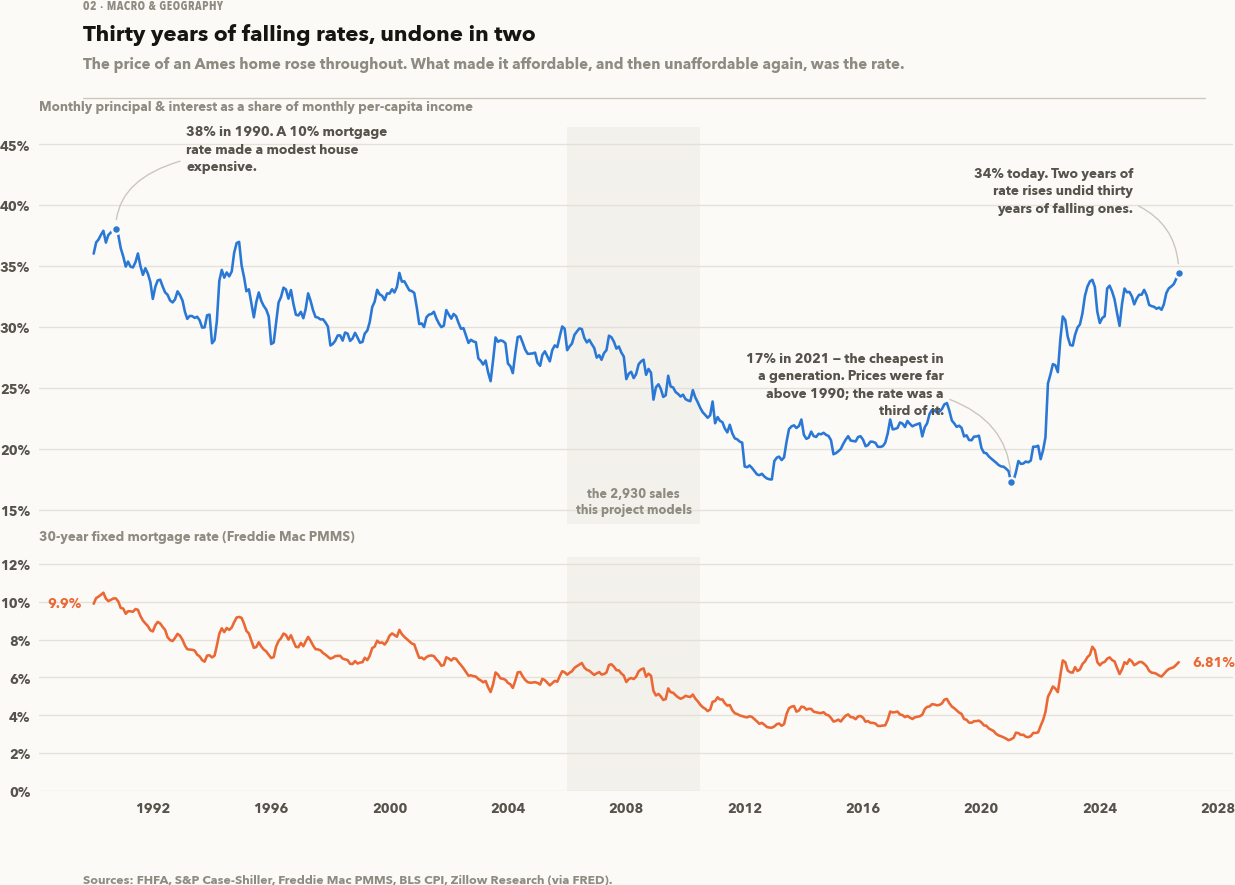

In [8]:
afford = pd.DataFrame({
    "price": price_level,
    "rate": macro["mortgage30us"] / 100,
    "income_pc": macro["income_pc_story"],
    "zhvi": macro["zhvi"],
}).dropna(subset=["price", "rate", "income_pc"]).loc["1990-01-01":]

afford["loan"] = afford["price"] * 0.80
afford["payment"] = [monthly_payment(l, r, 30) for l, r in zip(afford["loan"], afford["rate"])]
# Monthly per-capita personal income.  This ratio is not a household budget share -- it
# is a consistently-measured index of pressure, and its *path* is the object of interest.
afford["income_monthly"] = afford["income_pc"] / 12
afford["payment_to_income"] = afford["payment"] / afford["income_monthly"]
afford["price_to_income"] = afford["price"] / afford["income_pc"]

# Panel one is the point, panel two is the explanation, so panel one gets the room.
fig, axes = plt.subplots(2, 1, figsize=(11.6, 8.6), sharex=True,
                         gridspec_kw={"height_ratios": [1.7, 1]})

burden = afford["payment_to_income"]
rate = afford["rate"]
peak_i, trough_i = burden.idxmax(), burden.idxmin()
peak, trough, latest = burden.max(), burden.min(), burden.iloc[-1]
WINDOW = (pd.Timestamp("2006-01-01"), pd.Timestamp("2010-07-01"))

# --- panel 1: the payment burden -------------------------------------------
ax = axes[0]
# Headroom first: the callouts need somewhere to sit that is not on top of the line.
ax.set_ylim(trough * 0.80, peak * 1.22)
era(ax, *WINDOW, "the 2,930 sales\nthis project models")
ax.plot(burden.index, burden, color=SUBJECT, lw=1.7)

callout(ax, peak_i, peak,
        f"{peak:.0%} in {peak_i:%Y}. A 10% mortgage rate made a modest house expensive.",
        dx=46, dy=52, dot_color=SUBJECT, width=30)
callout(ax, trough_i, trough,
        f"{trough:.0%} in {trough_i:%Y} — the cheapest in a generation. Prices were far "
        f"above 1990; the rate was a third of it.",
        dx=-44, dy=64, ha="right", dot_color=SUBJECT, width=30)
callout(ax, burden.index[-1], latest,
        f"{latest:.0%} today. Two years of rate rises undid thirty years of falling ones.",
        dx=-30, dy=54, ha="right", dot_color=SUBJECT, width=24)

ax.yaxis.set_major_formatter(pct)
axis_note(ax, "Monthly principal & interest as a share of monthly per-capita income")

# --- panel 2: the rate that drives it --------------------------------------
ax = axes[1]
ax.set_ylim(0, rate.max() * 1.18)
era(ax, *WINDOW)
ax.plot(rate.index, rate, color=CONTRAST, lw=1.7)
label_end(ax, rate.index[-1], rate.iloc[-1], f"{rate.iloc[-1]:.2%}", color=CONTRAST)
annotate(ax, rate.index[0], rate.iloc[0], f"{rate.iloc[0]:.1%}", color=CONTRAST,
         offset=(-8, 0), ha="right")
ax.yaxis.set_major_formatter(pct)
axis_note(ax, "30-year fixed mortgage rate (Freddie Mac PMMS)")

finish(fig, "Thirty years of falling rates, undone in two",
       "The price of an Ames home rose throughout. What made it affordable, and then "
       "unaffordable again, was the rate.")
save(fig, "02_affordability")
plt.show()

In [9]:
cycle = afford.loc[["2006-01-01", "2008-01-01", "2010-01-01", "2012-01-01",
                    "2016-01-01", "2020-01-01", "2022-01-01", "2026-01-01"]]
cycle_table = cycle[["price", "rate", "payment", "payment_to_income", "price_to_income"]].copy()
cycle_table.index = cycle_table.index.strftime("%Y")
cycle_table.round(3)

,price,rate,payment,payment_to_income,price_to_income
date,,,,,
2006,155817.044,0.061,759.022,0.281,4.809
2008,161834.253,0.058,756.195,0.257,4.591
2010,155740.635,0.050,671.126,0.241,4.660
2012,158605.973,0.039,599.566,0.186,4.095
2016,178453.209,0.039,671.118,0.208,4.603
2020,206581.271,0.036,753.600,0.201,4.591
2022,235826.814,0.034,841.393,0.192,4.480
2026,306342.766,0.061,1485.533,0.316,5.432


The 2006–2010 window is the easy part of this chart. Payment burden peaked far more
recently, driven by rates rather than by Ames prices, which is why notebook 07
underwrites these properties at today's prices and today's cost of debt rather than 2007's.

### Rate shock: the price "duration" of a fixed payment

Hold the monthly payment constant and move the mortgage rate. The loan a buyer can
support moves inversely, and so does the price they can bid. This gives a direct measure of
a housing market's interest-rate sensitivity.

  saved reports/figures/02_rate_shock.png


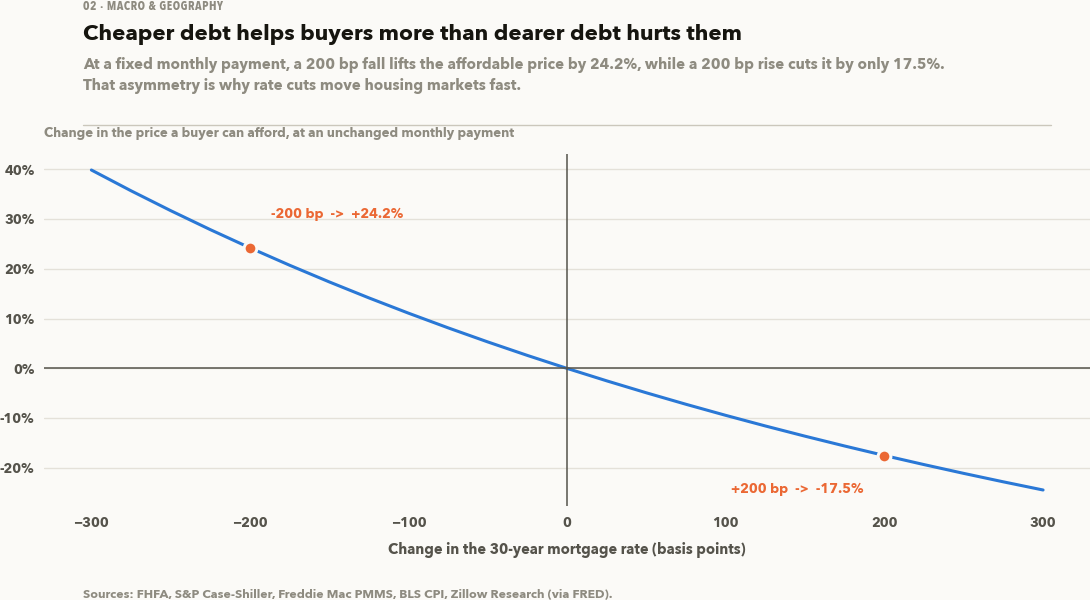

In [10]:
current_rate = afford["rate"].iloc[-1]
current_price = afford["price"].iloc[-1]
budget = monthly_payment(current_price * 0.80, current_rate, 30)

shocks = np.arange(-0.03, 0.0301, 0.0025)
rows = []
for shock in shocks:
    r = max(current_rate + shock, 0.0025)
    i, n = r / 12, 360
    supportable_loan = budget * (1 - (1 + i) ** -n) / i
    rows.append({"shock_bp": shock * 1e4, "rate": r,
                 "supportable_price": supportable_loan / 0.80})
duration = pd.DataFrame(rows)
duration["price_change"] = duration["supportable_price"] / current_price - 1

fig, ax = plt.subplots(figsize=(10.2, 6.0))
ax.plot(duration["shock_bp"], duration["price_change"], color=SUBJECT, lw=2.0)
ax.axhline(0, color=INK_SECONDARY, lw=1)
ax.axvline(0, color=INK_SECONDARY, lw=1)
for bp, dy in ((-200, 22), (200, -22)):
    row = duration.loc[duration["shock_bp"].round(0) == bp].iloc[0]
    ax.scatter([bp], [row["price_change"]], s=70, color=CONTRAST,
               edgecolor=SURFACE, linewidths=2, zorder=5)
    annotate(ax, bp, row["price_change"],
             f"{bp:+d} bp  ->  {row['price_change']:+.1%}", color=CONTRAST,
             offset=(14 if bp < 0 else -14, dy), ha="left" if bp < 0 else "right",
             fontweight="demibold")
ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("Change in the 30-year mortgage rate (basis points)")
axis_note(ax, "Change in the price a buyer can afford, at an unchanged monthly payment")
finish(fig, "Cheaper debt helps buyers more than dearer debt hurts them",
       f"At a fixed monthly payment, a 200 bp fall lifts the affordable price by "
       f"{duration.loc[duration['shock_bp'].round(0) == -200, 'price_change'].iloc[0]:.1%}, "
       f"while a 200 bp rise cuts it by only "
       f"{abs(duration.loc[duration['shock_bp'].round(0) == 200, 'price_change'].iloc[0]):.1%}. "
       f"That asymmetry is why rate cuts move housing markets fast.")
save(fig, "02_rate_shock")
plt.show()

In [11]:
dv01 = duration.loc[duration["shock_bp"].round(0) == 100, "price_change"].iloc[0]
print(f"+100 bp costs {abs(dv01):.1%} of supportable price at a constant payment")
print(f"   the effective 'duration' of Ames house prices is "
      f"about {abs(dv01) * 100:.1f}% per 100 bp")

+100 bp costs 9.4% of supportable price at a constant payment
   the effective 'duration' of Ames house prices is about 9.4% per 100 bp


That number is used later. Notebook 07's Monte Carlo draws mortgage rate and
exit cap rate as correlated shocks because of this mechanism: a rate rise
compresses what buyers can pay, which raises the cap rate an exit buyer demands.

## 3. Geography: the campus gradient

99.6% of properties have coordinates, so location becomes a measurable distance instead of
a 28-level categorical.

In [12]:
geo = normal.dropna(subset=["Latitude", "Longitude"]).copy()
geo["price_per_sf"] = geo["SalePrice"] / geo["Gr Liv Area"]
print(f"{len(geo):,} arm's-length sales with coordinates")
print(f"distance to ISU campus: {geo['dist_isu_mi'].min():.2f}–{geo['dist_isu_mi'].max():.2f} miles")

2,406 arm's-length sales with coordinates
distance to ISU campus: 0.46–3.64 miles


  saved reports/figures/02_campus_gradient.png


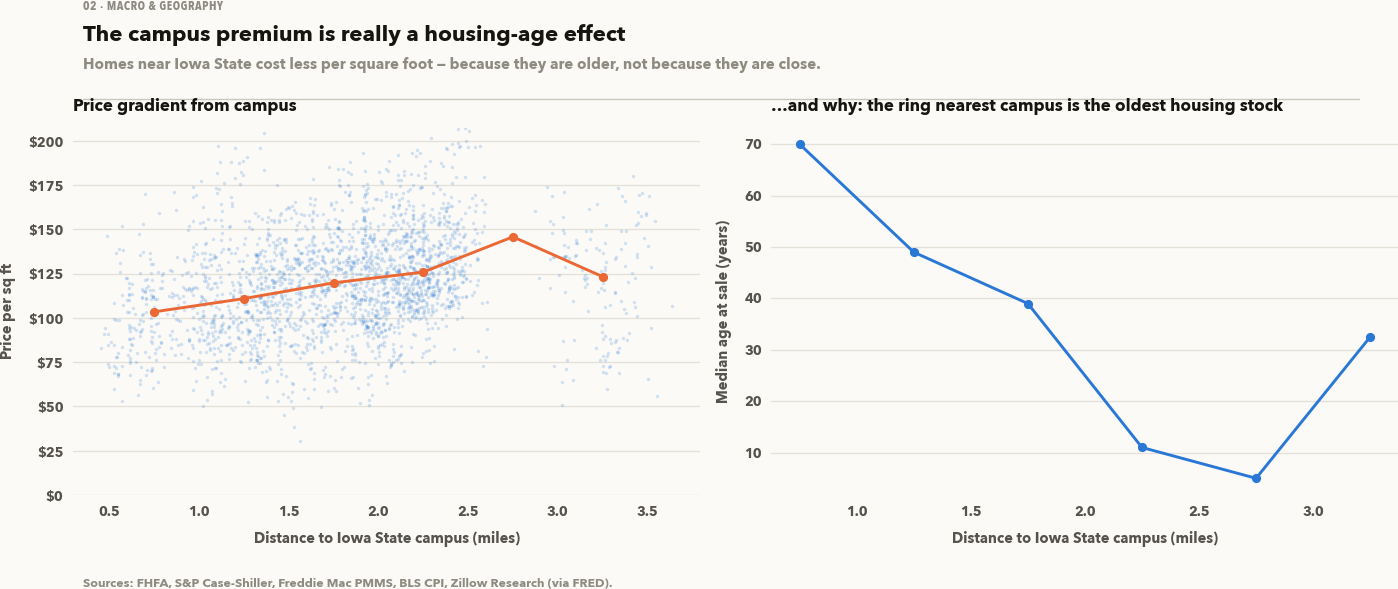

In [13]:
bins = np.arange(0, geo["dist_isu_mi"].max() + 0.5, 0.5)
geo["dist_bin"] = pd.cut(geo["dist_isu_mi"], bins)
binned = geo.groupby("dist_bin", observed=True).agg(
    n=("price_per_sf", "size"),
    median_psf=("price_per_sf", "median"),
    median_age=("house_age", "median"),
    median_qual=("Overall Qual", "median"),
)
binned = binned[binned["n"] >= 25]
binned["midpoint"] = [iv.mid for iv in binned.index]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.9))

axes[0].scatter(geo["dist_isu_mi"], geo["price_per_sf"], s=5, alpha=0.2,
                color=BLUE, linewidths=0)
axes[0].plot(binned["midpoint"], binned["median_psf"], color=ORANGE, marker="o",
             markersize=5, label="Median $/sq ft per half-mile ring")
axes[0].set_xlabel("Distance to Iowa State campus (miles)")
axes[0].set_ylabel("Price per sq ft")
axes[0].yaxis.set_major_formatter(money)
axes[0].set_ylim(0, geo["price_per_sf"].quantile(0.995))
titled(axes[0], "Price gradient from campus")

axes[1].plot(binned["midpoint"], binned["median_age"], color=BLUE,
             marker="o", markersize=5, label="Median house age (years)")
axes[1].set_xlabel("Distance to Iowa State campus (miles)")
axes[1].set_ylabel("Median age at sale (years)")
titled(axes[1], "…and why: the ring nearest campus is the oldest housing stock")
finish(fig, "The campus premium is really a housing-age effect",
       "Homes near Iowa State cost less per square foot — because they are older, not "
       "because they are close.")
save(fig, "02_campus_gradient")
plt.show()

The gradient runs the wrong way: price per square foot rises with distance from
campus, out to about three miles. The second panel shows why. The rings nearest
campus hold Ames's oldest housing stock, with a median age of 70 years inside one mile
against 10 years in the two-to-three-mile ring. Distance and age are confounded: they move
together, so neither can be credited with the effect without controlling for the other.

A short hedonic regression tests whether any campus effect remains once vintage is controlled for.

In [14]:
gradient = geo.groupby(pd.cut(geo["dist_isu_mi"], [0, 1, 2, 3, 10]), observed=True).agg(
    n=("SalePrice", "size"), median_price=("SalePrice", "median"),
    median_psf=("price_per_sf", "median"), median_age=("house_age", "median"),
    median_lot=("Lot Area", "median"))
gradient.round(0)

,n,median_price,median_psf,median_age,median_lot
dist_isu_mi,,,,,
"(0, 1]",233,140000.0,103.0,70.0,9350.0
"(1, 2]",1227,146900.0,116.0,43.0,9204.0
"(2, 3]",822,185000.0,126.0,10.0,9602.0
"(3, 10]",124,137750.0,123.0,32.0,8832.0


In [15]:
import statsmodels.api as sm

geo["log_psf"] = np.log(geo["price_per_sf"])
geo["log_lot"] = np.log(geo["Lot Area"])

uncontrolled = sm.OLS(geo["log_psf"], sm.add_constant(geo[["dist_isu_mi"]])).fit()
controlled = sm.OLS(
    geo["log_psf"],
    sm.add_constant(geo[["dist_isu_mi", "house_age", "Overall Qual",
                         "log_lot", "Yr Sold"]])).fit()

comparison = pd.DataFrame({
    "coefficient on distance to ISU": [uncontrolled.params["dist_isu_mi"],
                                       controlled.params["dist_isu_mi"]],
    "t-statistic": [uncontrolled.tvalues["dist_isu_mi"],
                    controlled.tvalues["dist_isu_mi"]],
    "p-value": [uncontrolled.pvalues["dist_isu_mi"],
                controlled.pvalues["dist_isu_mi"]],
    "R-squared": [uncontrolled.rsquared, controlled.rsquared],
}, index=["distance alone", "+ age, quality, lot size, sale year"])
comparison.round(4)

,coefficient on distance to ISU,t-statistic,p-value,R-squared
distance alone,0.1044,12.8296,0.0000,0.0641
"+ age, quality, lot size, sale year",-0.0004,-0.0554,0.9558,0.3542


**The campus gradient is entirely a vintage effect.** On its own, distance carries a
highly significant +10.4% per mile. Once house age, quality, lot size and sale year
enter, the coefficient collapses to −0.04% per mile with a *t* of −0.06. There is no
measurable willingness to pay for campus proximity per square foot in Ames once the
age and quality of the house are accounted for.

This is a textbook omitted-variable result, and it is why `ames.features` supplies
distance, bearing and house age as separate features rather than a single hand-built
"location score". A composite would have fused the two effects permanently, and the
model would have learned a campus premium that does not exist.

### Neighborhood map

No shapefile ships with the Ames data, so neighborhood boundaries are drawn as the
convex hull of each neighborhood's own sales. Real boundaries are not convex, so the map
is for orientation, not measurement.

  saved reports/figures/02_neighborhood_map.png


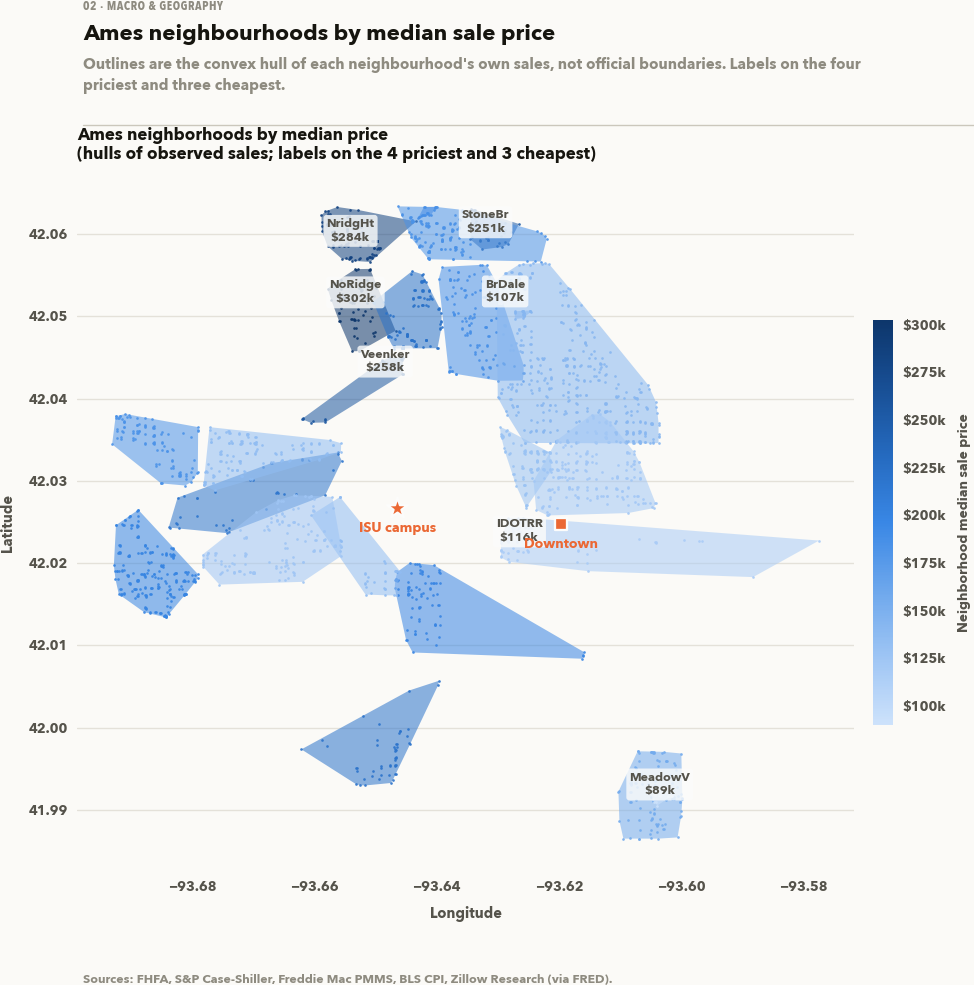

In [16]:
nb_stats = (geo.groupby("Neighborhood")
            .agg(n=("SalePrice", "size"), median_price=("SalePrice", "median"),
                 median_psf=("price_per_sf", "median"),
                 lat=("Latitude", "median"), lon=("Longitude", "median"))
            .query("n >= 15").sort_values("median_price", ascending=False))

fig, ax = plt.subplots(figsize=(9.5, 9.5))
norm = plt.Normalize(nb_stats["median_price"].min(), nb_stats["median_price"].max())

for name, row in nb_stats.iterrows():
    pts = geo.loc[geo["Neighborhood"] == name, ["Longitude", "Latitude"]].to_numpy()
    color = SEQUENTIAL(norm(row["median_price"]))
    if len(pts) >= 3:
        try:
            hull = ConvexHull(pts)
            ax.fill(pts[hull.vertices, 0], pts[hull.vertices, 1],
                    color=color, alpha=0.55, lw=0)
        except Exception:
            pass
    ax.scatter(pts[:, 0], pts[:, 1], s=3, color=color, linewidths=0, alpha=0.9)

for name in list(nb_stats.index[:4]) + list(nb_stats.index[-3:]):
    row = nb_stats.loc[name]
    ax.annotate(f"{name}\n{money(row['median_price'])}", (row["lon"], row["lat"]),
                fontsize=8, color=INK_SECONDARY, ha="center",
                bbox=dict(boxstyle="round,pad=0.25", fc="#fcfcfb", ec="none", alpha=0.8))

for (lat, lon), label, marker in [(ISU_CAMPUS, "ISU campus", "*"),
                                  (DOWNTOWN_AMES, "Downtown", "s")]:
    ax.scatter([lon], [lat], marker=marker, s=200 if marker == "*" else 70,
               color=ORANGE, edgecolor="#fcfcfb", linewidths=1.5, zorder=10)
    ax.annotate(label, (lon, lat), xytext=(0, -16), textcoords="offset points",
                ha="center", fontsize=9, color=ORANGE, fontweight="semibold")

sm = plt.cm.ScalarMappable(cmap=SEQUENTIAL, norm=norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label("Neighborhood median sale price", color=INK_SECONDARY, fontsize=9)
cbar.ax.yaxis.set_major_formatter(money)
cbar.outline.set_visible(False)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect(1 / np.cos(np.radians(42.03)))
ax.set_title("Ames neighborhoods by median price\n"
             "(hulls of observed sales; labels on the 4 priciest and 3 cheapest)")
finish(fig, "Ames neighbourhoods by median sale price",
       "Outlines are the convex hull of each neighbourhood's own sales, not official "
       "boundaries. Labels on the four priciest and three cheapest.")
save(fig, "02_neighborhood_map")
plt.show()

In [17]:
(nb_stats.drop(columns=["lat", "lon"])
 .assign(price_rank=range(1, len(nb_stats) + 1))
 .round(0).head(10))

,n,median_price,median_psf,price_rank
Neighborhood,,,,
NoRidge,67,302000.0,130.0,1
NridgHt,100,284000.0,158.0,2
Veenker,22,257500.0,141.0,3
StoneBr,35,251000.0,154.0,4
Somerst,114,222250.0,136.0,5
Timber,51,220000.0,138.0,6
ClearCr,38,218000.0,120.0,7
CollgCr,226,198700.0,135.0,8
Crawfor,88,198000.0,117.0,9


### Interactive map

Written to `reports/ames_map.html`: every arm's-length sale, coloured by price and
clickable for its attributes.

In [18]:
import folium
from folium.plugins import MarkerCluster

price_quintiles = pd.qcut(geo["SalePrice"], 5, labels=False)
quintile_colors = ["#cde2fb", "#9ec5f4", "#3987e5", "#256abf", "#0d366b"]

fmap = folium.Map(location=ISU_CAMPUS, zoom_start=13, tiles="OpenStreetMap")
cluster = MarkerCluster(name="Sales").add_to(fmap)
for (_, row), q in zip(geo.iterrows(), price_quintiles):
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=3.5, color=None, fill=True, fill_color=quintile_colors[q],
        fill_opacity=0.85,
        popup=folium.Popup(
            f"<b>{row['Neighborhood']}</b><br>{money(row['SalePrice'])}<br>"
            f"{row['Gr Liv Area']:,.0f} sq ft · built {row['Year Built']:.0f}<br>"
            f"Overall Qual {row['Overall Qual']:.0f} · sold {row['Yr Sold']:.0f}",
            max_width=240),
    ).add_to(cluster)

folium.Marker(ISU_CAMPUS, popup="Iowa State University",
              icon=folium.Icon(color="orange", icon="graduation-cap", prefix="fa")).add_to(fmap)
folium.Marker(DOWNTOWN_AMES, popup="Downtown Ames",
              icon=folium.Icon(color="orange", icon="building", prefix="fa")).add_to(fmap)

map_path = REPORTS / "ames_map.html"
fmap.save(str(map_path))
print(f"saved {map_path.relative_to(map_path.parents[1])}  ({map_path.stat().st_size / 1e6:.1f} MB)")

saved reports/ames_map.html  (2.7 MB)


## 4. Summary

| Finding | Where it is used |
|---|---|
| Ames fell 4.3% peak-to-trough vs 27.4% nationally | The temporal split is a mild shift, so nb 03's degradation is a lower bound |
| Real Ames prices fell 11% by 2012 while nominal prices held | Framing for every nominal figure in nb 07/06 |
| FHFA-anchored 2026 price ($310k) sits 11% above Zillow ZHVI ($280k) | Both carried into nb 07; the gap is treated as an uncertainty on going-in value |
| Price duration ≈ 9.4% per 100 bp | Motivates the rate/cap-rate correlation in nb 07's Monte Carlo |
| The campus gradient is entirely a housing-age effect (t = −0.06 once controlled) | Distance, bearing and age stay as separate features; no composite location score |
| Ames's own history contains no severe downturn | nb 08 must impose the supervisory −30% shock explicitly |